In [2]:
import numpy as np
import juliacall
import pandas as pd

from resources.BulkConversion import ThermoBulk
MAGEMin_C = juliacall.newmodule("MAGEMin_C")
MAGEMin_C.seval("using MAGEMin_C")

from juliacall import Main as jl, convert as jlconvert

compositions = pd.read_csv('compositions.csv')
model_composition = compositions.loc[4]

bulk = ThermoBulk()
bulk.get_bulk_compositions(model_composition, 'NCKFMASHTOCr', XFe3=0.03)
comp = bulk.thermocalc
oxides = list(comp.keys())
values = list(comp.values())
print(oxides)
print(values)


O2 is was not provided
['SiO2', 'TiO2', 'Al2O3', 'Cr2O3', 'FeO', 'MgO', 'CaO', 'Na2O', 'K2O', 'H2O', 'O']
[39.8296, 0.1105, 2.0009, 0.1708, 5.5059, 49.33, 2.9194, 0.0419, 0.0055, 0.0029, 0.0826]
Using libMAGEMin.dylib from MAGEMin_jll


In [33]:
data    = MAGEMin_C.Initialize_MAGEMin("ig", verbose=False)
P,T     = 10.0, 1500.0
Xoxides = jlconvert(jl.Vector[jl.String], oxides)
X       = jlconvert(jl.Vector[jl.Float64], values)
sys_in  = "mol"
out     = MAGEMin_C.single_point_minimization(P, T, data, X=X, Xoxides=Xoxides, sys_in=sys_in)

dT_dP = 1.1
dT =1
dP = dT/dT_dP

out2     = MAGEMin_C.single_point_minimization(P+dP, T+dT, data, X=X, Xoxides=Xoxides, sys_in=sys_in)

T_m = jlconvert(jl.Vector[jl.Float64], np.arange(1000,2500,20))
#P_m = jlconvert(jl.Vector[jl.Float64], [P])
P_m = jlconvert(jl.Vector[jl.Float64], [0.1 for i in range(len(T_m))])
out_m     = MAGEMin_C.multi_point_minimization(P_m, T_m, data, X=X, Xoxides=Xoxides, sys_in=sys_in)





Computing 75 points... 100%|█████████████████████████████| Time: 0:00:23


In [45]:
#for i in range(len(out_m)):
 #   print(f"P : {P_m[i]}, T : {T_m[i]}, Phases : {out_m[i].ph}, X : {out_m[i].ph_frac}")
#print(out_m.__getattr__(1))

def check_melt_frac(out):
    if 'liq' in out.ph:
        idx = out.ph.index('liq')
        return out.ph_frac[idx]
    else:
        return 0
    
def initial_search(P, T_range, data, X, Xoxides, sys_in, n_points=100):
    T_vec = jlconvert(jl.Vector[jl.Float64], np.linspace(T_range[0], T_range[1], n_points))
    P_vec = jlconvert(jl.Vector[jl.Float64], [P for p in range(len(T_vec))])
    print(f"Searching at P : {P} Kbar, between {T_range[0]} and {T_range[1]} C")
    out_m = MAGEMin_C.multi_point_minimization(P_vec, T_vec, data, X=X, Xoxides=Xoxides, sys_in=sys_in)
    solidus_T_interval = None
    liquidus_T_interval = None
    for i in range(len(out_m)):
        if solidus_T_interval == None:
            if check_melt_frac(out_m[i]) > 0:
                solidus_T_interval = (T_vec[i-1], T_vec[i])
            else:
                pass
        if liquidus_T_interval == None:
            if check_melt_frac(out_m[i]) == 1:
                liquidus_T_interval = (T_vec[i-1], T_vec[i])
            else:
                pass
        else:
            pass
    return solidus_T_interval, liquidus_T_interval

Ts_int, Tl_int = initial_search(0.1, (1000, 2500), data, X, Xoxides, sys_in, n_points=50)

print(Ts_int)
print(Tl_int)



Searching along P : 0.1 Kbar, between 1000 and 2500 C
(1091.8367346938776, 1122.4489795918366)
(1765.3061224489795, 1795.9183673469388)


In [12]:


def check_melt_frac(out):
    if 'liq' in out.ph:
        idx = out.ph.index('liq')
        return out.ph_frac[idx]
    else:
        return 0

def get_phase_data(out):
    phases_dict = {}

    for index in range(len(out.ph)):
        phases_dict[index] = {'name': out.ph[index], 'frac':out.ph_frac[index], 'alpha':out.SS_vec[index].alpha}

    return phases_dict

print(get_phase_data(out))
print(check_melt_frac(out))

phases_dict = {p:f for p,f in zip(out.ph,out.ph_frac)}

#print(dir(out[0].PP))

for p,f in phases_dict.items():
    print(f"Phase : {p} - {f}")

print(f"Cp : {out.cp :.3f}")
print(f"Enthalpy : {out.enthalpy :.3f}")
print(f"Entropy : {out.entropy :.3f}")
print(f"V : {out.V :.3f}")

print ("----------------------------------")

phases2_dict = {p2:f2 for p2,f2 in zip(out2.ph,out2.ph_frac)}

for p2,f2 in phases2_dict.items():
    print(f"Phase : {p2} - {f2}")

print(f"Cp : {out2.cp :.3f}")
print(f"Enthalpy : {out2.enthalpy :.3f}")
print(f"Entropy : {out2.entropy :.3f}")
print(f"V : {out2.V :.3f}")

print ("----------------------------------")

print(f"dT/dP : {dT/dP :.2f}")
print(f"dG : {out2.G_system - out.G_system :.3f}")
print(f"dG/dP : {(out2.G_system - out.G_system)/dP :.3f}")
print(f"dG/dT : {(out2.G_system - out.G_system)/dT :.3f}")
print(f"dT : {dT :.2f}, dP : {dP :.2f}")
print(f"dF : {phases2_dict['liq'] - phases_dict['liq'] :.5f}")
print(f"dS : {out2.entropy - out.entropy :.5f}")
print(f"dH : {out2.enthalpy - out.enthalpy :.5f}")
print(f"dV : {out2.V - out.V :.5f}")
print(f"dV/dT : {(out2.V - out.V)/dT :.5f}")

print(out.ph, out.ph_frac)
print(out.SS_vec[0].emNames)
print(out.SS_vec[0].alpha)
print(out.SS_vec[1].emNames)
print(out.SS_vec[1].alpha)

print(out2.ph, out2.ph_frac)
print(out2.SS_vec[0].emNames)
print(out2.SS_vec[0].alpha)
print(out2.SS_vec[1].emNames)
print(out2.SS_vec[1].alpha)

NULL
Julia:
2-element Vector{MAGEMin_C.gmin_struct{Float64, Int64}}:
 Pressure          : 0.001      [kbar]
Temperature       : 1000.0    [Celsius]
     Stable phase | Fraction (mol fraction) 
              fsp   0.07728 
              cpx   0.04501 
               ol   0.54677 
              opx   0.32928 
               fl   4.0e-5 
              spn   0.00161 
     Stable phase | Fraction (wt fraction) 
              fsp   0.0784 
              cpx   0.04669 
               ol   0.54564 
              opx   0.32737 
               fl   2.0e-5 
              spn   0.00189 
     Stable phase | Fraction (vol fraction) 
              fsp   0.08341 
              cpx   0.04198 
               ol   0.48628 
              opx   0.29333 
               fl   0.09352 
              spn   0.00147 
Gibbs free energy : -840.977353  (57 iterations; 189.26 ms)
Oxygen fugacity          : -9.820891818167718
Delta QFM                : 1.2712198607750562

 Pressure          : 5.0      [kbar]
Temperatu

In [50]:
data    = MAGEMin_C.Initialize_MAGEMin("ig", verbose=False)
P,T     = 10.0, 1500.0
Xoxides = jlconvert(jl.Vector[jl.String], oxides)
X       = jlconvert(jl.Vector[jl.Float64], values)
sys_in  = "mol"
out     = MAGEMin_C.single_point_minimization(P, T, data, X=X, Xoxides=Xoxides, sys_in=sys_in)

dT_dP = 1.1
dT =1
dP = dT/dT_dP

out2     = MAGEMin_C.single_point_minimization(P+dP, T+dT, data, X=X, Xoxides=Xoxides, sys_in=sys_in)

def check_melt_frac(out):
    if 'liq' in out.ph:
        idx = out.ph.index('liq')
        return out.ph_frac[idx]
    else:
        return 0

def initial_search(P_array, T_array, data, X, Xoxides, sys_in):
    print(f"Searching at P : {P_array[0]} Kbar, between {T_array[0]} and {T_array[1]} C")
    out_m = MAGEMin_C.multi_point_minimization(P_array, T_array, data, X=X, Xoxides=Xoxides, sys_in=sys_in)
    solidus_T_interval = None
    liquidus_T_interval = None
    for i in range(len(out_m)):
        if solidus_T_interval == None:
            if check_melt_frac(out_m[i]) > 0:
                solidus_T_interval = (T_array[i-1], T_array[i])
            else:
                pass
        if liquidus_T_interval == None:
            if check_melt_frac(out_m[i]) == 1:
                liquidus_T_interval = (T_array[i-1], T_array[i])
            else:
                pass
        else:
            pass
    return solidus_T_interval, liquidus_T_interval

def binary_search_boundary(P, T_low, T_high, condition_func, boundary_name, tolerance=0.5):
    """
    Binary search to find temperature boundary within tolerance.
    
    Args:
        P: Pressure in GPa
        T_low: Lower temperature bound
        T_high: Upper temperature bound
        condition_func: Function that returns True above boundary
        tolerance: Temperature tolerance in K
    
    Returns:
        float: Temperature at boundary
    """
    iteration = 0
    while (T_high - T_low) > tolerance:
        iteration += 1
        print(f"P : {P}, Boundary : {boundary_name}, iteration : {iteration}, T_low : {T_low}, T_high : {T_high}")
        T_mid = (T_low + T_high) / 2
        if condition_func(T_mid):
            T_high = T_mid
        else:
            T_low = T_mid
            
    return (T_low + T_high) / 2

def find_phase_boundaries(data, X, Xoxides, sys_in, P, T_range=(1000, 2500), tolerance=1, n_points_initial=50):
    """
    Find solidus and liquidus temperatures at a given pressure using binary search.
    If return_all_points is True, returns arrays of all T points and their melt fractions.
    
    Args:
        P: Pressure in GPa or array of pressures
        Trange: Tuple of (min_temp, max_temp) in K
        tolerance: Temperature tolerance in K
        return_all_points: If True, returns full T and melt fraction arrays
    
    Returns:
        if return_all_points=False:
            tuple: (solidus_T, liquidus_T) in K, or (None, None) if not found
        if return_all_points=True:
            tuple: (temperatures, melt_fractions, solidus_T, liquidus_T)
    """
    T_array = jlconvert(jl.Vector[jl.Float64], np.linspace(T_range[0], T_range[1], n_points_initial))
    P_array = jlconvert(jl.Vector[jl.Float64], [P for p in range(len(T_array))])

    Ts_int, Tl_int = initial_search(P_array, T_array, data, X, Xoxides, sys_in)
    
    # Binary search for solidus
    solidus_T = binary_search_boundary(
        P, Ts_int[0], Ts_int[1],
        lambda t: check_melt_frac(MAGEMin_C.single_point_minimization(P, t, data, X=X, Xoxides=Xoxides, sys_in=sys_in)) > 0,
        'solidus',
        tolerance
    )
    
    # Binary search for liquidus
    liquidus_T = binary_search_boundary(
        P, Tl_int[0], Tl_int[1],
        lambda t: check_melt_frac(MAGEMin_C.single_point_minimization(P, t, data, X=X, Xoxides=Xoxides, sys_in=sys_in)) >= 1,
        'liquidus',
        tolerance
    )
    
    return solidus_T, liquidus_T


data    = MAGEMin_C.Initialize_MAGEMin("ig", verbose=False)
#P,T     = 10.0, 1500.0
Xoxides = jlconvert(jl.Vector[jl.String], oxides)
X       = jlconvert(jl.Vector[jl.Float64], values)
sys_in  = "mol"

pressures = np.linspace(0, 50, 10)  # 11 points from 5 to 15 GPa
solidus_points = []
liquidus_points = []


for P in pressures:
    sol_T, liq_T = find_phase_boundaries(data, X, Xoxides, sys_in,P, T_range=(1000, 2500), tolerance=0.5)
    if sol_T is not None:
        solidus_points.append((P, sol_T))
        liquidus_points.append((P, liq_T))

solidus_points = np.array(solidus_points)
liquidus_points = np.array(liquidus_points)

Searching at P : 0.0 Kbar, between 1000.0 and 1030.6122448979593 C


UnboundLocalError: local variable 'solidus_T_interval' referenced before assignment

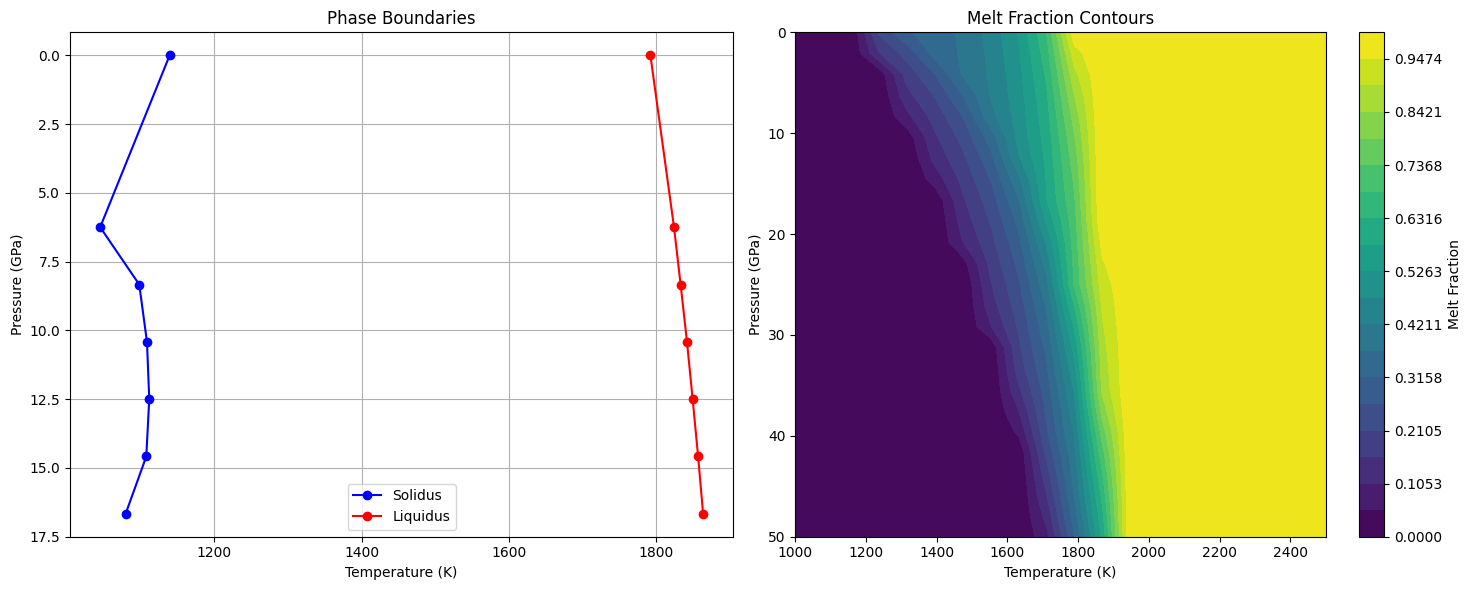

In [50]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot phase boundaries
ax1.plot(solidus_points[:,1], solidus_points[:,0],'b-o', label='Solidus')
ax1.plot(liquidus_points[:,1], liquidus_points[:,0], 'r-o', label='Liquidus')
ax1.set_ylabel('Pressure (GPa)')
ax1.set_xlabel('Temperature (K)')
ax1.invert_yaxis()
ax1.set_title('Phase Boundaries')
ax1.legend()
ax1.grid(True)

# Plot melt fraction contours
P_mesh, T_mesh = np.meshgrid(pressures, all_temperatures[0])
melt_mesh = np.array(all_melt_fractions).T
contours = ax2.contourf(T_mesh, P_mesh, melt_mesh, levels=np.linspace(0, 1,20))
plt.colorbar(contours, ax=ax2, label='Melt Fraction')
ax2.set_ylabel('Pressure (GPa)')
ax2.set_xlabel('Temperature (K)')
ax2.invert_yaxis()
ax2.set_title('Melt Fraction Contours')

plt.tight_layout()
plt.show()